# Défi quotidien : BaristaBot — un agent LangGraph + API Gemini

Ce notebook construit **BaristaBot**, un système de commande de café conversationnel,
en utilisant **LangGraph** pour la gestion d'état et de graphe, et l'**API Gemini**
(via LangChain) comme moteur de conversation.

Toutes les cellules marquées `...` dans l'énoncé original ont été complétées ci-dessous,
et le notebook est organisé en étapes progressives, de la version la plus simple
(un seul tour de dialogue) jusqu'au système complet avec menu dynamique et gestion de commande.

## 1. Installation des dépendances

In [1]:
%pip install -qU "langgraph==1.0.5" "langgraph-prebuilt==1.0.5" "langgraph-checkpoint==3.0.1" \
    "langchain-google-genai==4.1.2" "google-genai==1.56.0"

# Note : on epingle explicitement langgraph-prebuilt et langgraph-checkpoint a des versions
# compatibles avec langgraph==1.0.5. Sans cela, pip installe la derniere version de
# langgraph-prebuilt (>=1.0.9), qui importe ExecutionInfo/ServerInfo depuis langgraph.runtime,
# des classes introduites seulement dans langgraph>=1.1 -> ImportError au moment du
# "from langgraph.prebuilt import ToolNode".
#
# IMPORTANT : apres cette installation, redemarrez le runtime/kernel (Kaggle: bouton
# "restart session" ; Colab: Runtime > Restart runtime) avant de reexecuter les cellules,
# sinon les anciens modules deja importes restent en cache.

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 53.3/53.3 kB 1.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 157.1/157.1 kB 5.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 46.2/46.2 kB 1.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 65.6/65.6 kB 2.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 426.6/426.6 kB 13.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 98.2/98.2 kB 2.6 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
langchain 1.3.11 requires langgraph<1.3.0,>=1.2.5, but you have langgraph 1.0.5 which is incompatible.
google-adk 2.3.0 requires google-genai<3,>=2.8, but you have google-genai 1.56.0 which is incompatible.


## 2. Configuration de la clé API

Sur Kaggle, la clé est récupérée via `kaggle_secrets`. En dehors de Kaggle (Colab, local),
on utilise une variable d'environnement `GOOGLE_API_KEY` ou une saisie interactive de secours.

In [2]:
import os

try:
    # Fonctionne uniquement sur Kaggle.
    from kaggle_secrets import UserSecretsClient
    GOOGLE_API_KEY = UserSecretsClient().get_secret("GOOGLE_API_KEY")
    os.environ["GOOGLE_API_KEY"] = GOOGLE_API_KEY
except ImportError:
    # Hors Kaggle : on suppose que GOOGLE_API_KEY est déjà dans l'environnement,
    # sinon on la demande de façon sécurisée (sans l'afficher à l'écran).
    if "GOOGLE_API_KEY" not in os.environ:
        import getpass
        os.environ["GOOGLE_API_KEY"] = getpass.getpass("Entrez votre GOOGLE_API_KEY : ")

print("Clé API configurée :", "GOOGLE_API_KEY" in os.environ)

Entrez votre GOOGLE_API_KEY : ··········
Clé API configurée : True


## 3. Définition de l'état et des instructions système

`OrderState` est le schéma d'état partagé par tous les nœuds du graphe : l'historique de
conversation, la commande en cours, et un indicateur de fin de commande.

In [3]:
from typing import Annotated
from typing_extensions import TypedDict

from langgraph.graph.message import add_messages


class OrderState(TypedDict):
    """État représentant la conversation de commande du client."""

    # La conversation. Ceci préserve l'historique de conversation entre les
    # nœuds. L'annotation `add_messages` indique à LangGraph que l'état est
    # mis à jour par ajout des messages retournés, et non par remplacement.
    messages: Annotated[list, add_messages]

    # La commande en cours du client.
    order: list[str]

    # Indicateur signalant que la commande est passée et terminée.
    finished: bool

/usr/local/lib/python3.12/dist-packages/langgraph/cache/base/__init__.py:8: LangChainPendingDeprecationWarning: The default value of `allowed_objects` will change in a future version. Pass an explicit value (e.g., allowed_objects='messages' or allowed_objects='core') to suppress this warning.
  from langgraph.checkpoint.serde.jsonplus import JsonPlusSerializer


In [4]:
# L'instruction système définit le comportement attendu du chatbot et inclut
# les règles indiquant quand appeler les différentes fonctions, ainsi que les
# règles de conversation, comme le ton et les sujets autorisés.
BARISTABOT_SYSINT = (
    "system",  # 'system' indique que le message est une instruction système.
    "You are a BaristaBot, an interactive cafe ordering system. A human will talk to you about the "
    "available products you have and you will answer any questions about menu items (and only about "
    "menu items - no off-topic discussion, but you can chat about the products and their history). "
    "The customer will place an order for 1 or more items from the menu, which you will structure "
    "and send to the ordering system after confirming the order with the human. "
    "\n\n"
    "Add items to the customer's order with add_to_order, and reset the order with clear_order. "
    "To see the contents of the order so far, call get_order (this is shown to you, not the user) "
    "Always confirm_order with the user (double-check) before calling place_order. Calling confirm_order will "
    "display the order items to the user and returns their response to seeing the list. Their response may contain modifications. "
    "Always verify and respond with drink and modifier names from the MENU before adding them to the order. "
    "If you are unsure a drink or modifier matches those on the MENU, ask a question to clarify or redirect. "
    "You only have the modifiers listed on the menu. "
    "Once the customer has finished ordering items, Call confirm_order to ensure it is correct then make "
    "any necessary updates and then call place_order. Once place_order has returned, thank the user and "
    "say goodbye!",
)

# Ceci est le message par lequel le système ouvre la conversation.
WELCOME_MSG = "Welcome to the BaristaBot cafe. Type `q` to quit. How may I serve you today?"

## 4. Un chatbot à un seul tour

Premier graphe minimal : un unique nœud `chatbot` qui enveloppe un appel au modèle Gemini.

In [5]:
from langgraph.graph import StateGraph, START, END
from langchain_google_genai import ChatGoogleGenerativeAI

# Essayez différents modèles. Les modèles `pro` donnent les meilleurs résultats,
# en particulier avec l'appel d'outils. Les modèles `flash` sont très rapides
# et constituent un bon choix si vous avez besoin d'un quota gratuit plus élevé.
# Voir les différences de fonctionnalités et de quotas ici : https://ai.google.dev/pricing
# Remarque : utilisez l'identifiant de modèle versionné exact (pas de suffixe
# "-latest" sur "gemini-2.5-flash" lui-même) ; l'alias "gemini-flash-latest"
# fonctionne aussi et pointe toujours vers le dernier modèle Flash stable.
llm = ChatGoogleGenerativeAI(model="gemini-2.5-flash")


def chatbot(state: OrderState) -> OrderState:
    """Le chatbot lui-même. Un simple wrapper autour de l'interface de chat du modèle."""
    message_history = [BARISTABOT_SYSINT] + state["messages"]
    return {"messages": [llm.invoke(message_history)]}


# Mise en place du graphe initial à partir de la définition de notre état.
graph_builder = StateGraph(OrderState)

# Ajoute la fonction chatbot au graphe de l'application comme un nœud appelé "chatbot".
graph_builder.add_node("chatbot", chatbot)

# Définit le nœud chatbot comme point d'entrée de l'application.
graph_builder.add_edge(START, "chatbot")

chat_graph = graph_builder.compile()

## 5. Visualiser le graphe

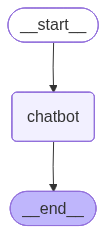

In [6]:
from IPython.display import Image

Image(chat_graph.get_graph().draw_mermaid_png())

## 6. Exécuter le graphe pour un premier tour de dialogue

In [7]:
from pprint import pprint

user_msg = "Hello, what can you get me?"
state = chat_graph.invoke({"messages": [("user", user_msg)]})

# L'objet état contient beaucoup d'informations. Décommentez les lignes pprint pour tout voir.
# pprint(state)

# Remarquez que l'état final contient maintenant 2 messages : notre HumanMessage,
# et un AIMessage supplémentaire.
for msg in state["messages"]:
    print(f"{type(msg).__name__}: {msg.content}")

HumanMessage: Hello, what can you get me?
AIMessage: Hello! Welcome to BaristaBot! I'd be happy to help you with your order.

Here's our menu:

**Coffee & Espresso**
*   **Espresso** - $3.00 (a concentrated shot of coffee)
*   **Americano** - $3.50 (espresso with hot water)
*   **Latte** - $4.50 (espresso with steamed milk and a thin layer of foam)
*   **Cappuccino** - $4.00 (espresso with steamed milk and a thick layer of foam)
*   **Mocha** - $5.00 (espresso with chocolate, steamed milk, and whipped cream)
*   **Drip Coffee** - $2.50 (freshly brewed coffee)

**Teas**
*   **Green Tea** - $3.00 (light and refreshing)
*   **Black Tea** - $3.00 (classic and robust)
*   **Herbal Tea** - $3.00 (caffeine-free and soothing)

**Pastries**
*   **Croissant** - $3.00 (buttery, flaky pastry)
*   **Muffin** - $2.75 (available in various flavors, please ask for today's selection!)
*   **Scone** - $3.25 (a delightful baked good, often with fruit)

**Modifiers (Add-ons)**
*   **Extra Shot of Espresso

## 7. Un second tour de dialogue manuel

In [8]:
user_msg = "Oh interesting, what teas do you have?"

state["messages"].append(("user", user_msg))
state = chat_graph.invoke(state)

# pprint(state)
for msg in state["messages"]:
    print(f"{type(msg).__name__}: {msg.content}")

HumanMessage: Hello, what can you get me?
AIMessage: Hello! Welcome to BaristaBot! I'd be happy to help you with your order.

Here's our menu:

**Coffee & Espresso**
*   **Espresso** - $3.00 (a concentrated shot of coffee)
*   **Americano** - $3.50 (espresso with hot water)
*   **Latte** - $4.50 (espresso with steamed milk and a thin layer of foam)
*   **Cappuccino** - $4.00 (espresso with steamed milk and a thick layer of foam)
*   **Mocha** - $5.00 (espresso with chocolate, steamed milk, and whipped cream)
*   **Drip Coffee** - $2.50 (freshly brewed coffee)

**Teas**
*   **Green Tea** - $3.00 (light and refreshing)
*   **Black Tea** - $3.00 (classic and robust)
*   **Herbal Tea** - $3.00 (caffeine-free and soothing)

**Pastries**
*   **Croissant** - $3.00 (buttery, flaky pastry)
*   **Muffin** - $2.75 (available in various flavors, please ask for today's selection!)
*   **Scone** - $3.25 (a delightful baked good, often with fruit)

**Modifiers (Add-ons)**
*   **Extra Shot of Espresso

## 8. Ajouter un nœud « humain »

Plutôt que de relancer manuellement le graphe en Python, on ajoute un nœud `human` qui affiche
la dernière réponse du modèle et récupère la saisie de l'utilisateur.

In [9]:
from langchain_core.messages.ai import AIMessage


def human_node(state: OrderState) -> OrderState:
    """Affiche le dernier message du modèle à l'utilisateur, et récupère sa saisie."""
    last_msg = state["messages"][-1]
    print("Model:", last_msg.content)

    user_input = input("User: ")

    # Si l'utilisateur semble vouloir quitter, on marque la conversation comme terminée.
    if user_input in {"q", "quit", "exit", "goodbye"}:
        state["finished"] = True

    return state | {"messages": [("user", user_input)]}


def chatbot_with_welcome_msg(state: OrderState) -> OrderState:
    """Le chatbot lui-même. Un wrapper autour de l'interface de chat du modèle."""

    if state["messages"]:
        # S'il y a déjà des messages, on poursuit la conversation avec le modèle Gemini.
        new_output = llm.invoke([BARISTABOT_SYSINT] + state["messages"])
    else:
        # S'il n'y a pas encore de messages, on démarre avec le message de bienvenue.
        new_output = AIMessage(content=WELCOME_MSG)

    return state | {"messages": [new_output]}


# On commence la construction d'un nouveau graphe.
graph_builder = StateGraph(OrderState)

# Ajoute les nœuds chatbot et human au graphe de l'application.
graph_builder.add_node("chatbot", chatbot_with_welcome_msg)
graph_builder.add_node("human", human_node)

# On repart du chatbot.
graph_builder.add_edge(START, "chatbot")

# Le chatbot ira toujours vers le nœud human ensuite.
graph_builder.add_edge("chatbot", "human")

## 9. Sortir de la boucle avec une transition conditionnelle

Sans condition de sortie, `human -> chatbot -> human -> ...` boucle indéfiniment.
On ajoute une arête conditionnelle : si l'utilisateur a demandé à quitter (`finished=True`),
on termine le graphe (`END`), sinon on repart vers `chatbot`.

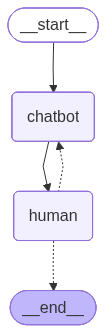

In [10]:
from typing import Literal


def maybe_exit_human_node(state: OrderState) -> Literal["chatbot", "__end__"]:
    """Route vers le chatbot, sauf si l'utilisateur semble vouloir quitter."""
    if state.get("finished", False):
        return END
    else:
        return "chatbot"


graph_builder.add_conditional_edges("human", maybe_exit_human_node)

chat_with_human_graph = graph_builder.compile()

Image(chat_with_human_graph.get_graph().draw_mermaid_png())

## 10. Ajouter un menu « en direct »

Le menu est exposé comme un outil (`tool`) plutôt que codé en dur dans le prompt système,
pour simuler un système capable de refléter un stock qui varie.
`get_menu` est un outil *sans état* (il ne modifie pas la commande) : il peut donc être
appelé automatiquement par un `ToolNode`.

In [11]:
from langchain_core.tools import tool


@tool
def get_menu() -> str:
    """Fournit le menu à jour."""
    # Ceci n'est qu'un texte codé en dur, mais on pourrait le connecter à une
    # base de données de stock en temps réel, ou utiliser les capacités
    # multimodales de Gemini pour prendre des photos en direct du menu à
    # craie du café ou des produits sur le comptoir et les assembler en entrée.

    return """
    MENU:
    Coffee Drinks:
    Espresso
    Americano
    Cold Brew

    Coffee Drinks with Milk:
    Latte
    Cappuccino
    Cortado
    Macchiato
    Mocha
    Flat White

    Tea Drinks:
    English Breakfast Tea
    Green Tea
    Earl Grey

    Tea Drinks with Milk:
    Chai Latte
    Matcha Latte
    London Fog

    Other Drinks:
    Steamer
    Hot Chocolate

    Modifiers:
    Milk options: Whole, 2%, Oat, Almond, 2% Lactose Free; Default option: whole
    Espresso shots: Single, Double, Triple, Quadruple; default: Double
    Caffeine: Decaf, Regular; default: Regular
    Hot-Iced: Hot, Iced; Default: Hot
    Sweeteners (option to add one or more): vanilla sweetener, hazelnut sweetener, caramel sauce, chocolate sauce, sugar free vanilla sweetener
    Special requests: any reasonable modification that does not involve items not on the menu, for example: 'extra hot', 'one pump', 'half caff', 'extra foam', etc.

    "dirty" means add a shot of espresso to a drink that doesn't usually have it, like "Dirty Chai Latte".
    "Regular milk" is the same as 'whole milk'.
    "Sweetened" means add some regular sugar, not a sweetener.

    Soy milk has run out of stock today, so soy is not available.
  """

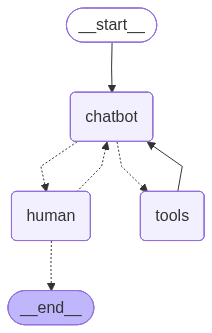

In [12]:
from langgraph.prebuilt import ToolNode


# Définit les outils et crée un nœud "tools".
tools = [get_menu]
tool_node = ToolNode(tools)

# Attache les outils au modèle afin qu'il sache ce qu'il peut appeler.
llm_with_tools = llm.bind_tools(tools)


def maybe_route_to_tools(state: OrderState) -> Literal["tools", "human"]:
    """Route vers le nœud human ou tools, selon qu'un appel d'outil est effectué ou non."""
    if not (msgs := state.get("messages", [])):
        raise ValueError(f"No messages found when parsing state: {state}")

    # On route uniquement en fonction du dernier message.
    msg = msgs[-1]

    # Quand le chatbot retourne des tool_calls, on route vers le nœud "tools".
    if hasattr(msg, "tool_calls") and len(msg.tool_calls) > 0:
        return "tools"
    else:
        return "human"


def chatbot_with_tools(state: OrderState) -> OrderState:
    """Le chatbot avec outils. Un simple wrapper autour de l'interface de chat du modèle."""
    defaults = {"order": [], "finished": False}

    if state["messages"]:
        new_output = llm_with_tools.invoke([BARISTABOT_SYSINT] + state["messages"])
    else:
        new_output = AIMessage(content=WELCOME_MSG)

    # Met en place des valeurs par défaut si elles ne sont pas déjà définies,
    # puis reporte l'état fourni, en ne remplaçant que le champ "messages".
    return defaults | state | {"messages": [new_output]}


graph_builder = StateGraph(OrderState)

# Ajoute les nœuds, y compris le nouveau tool_node.
graph_builder.add_node("chatbot", chatbot_with_tools)
graph_builder.add_node("human", human_node)
graph_builder.add_node("tools", tool_node)

# Le chatbot peut aller vers tools, ou vers human.
graph_builder.add_conditional_edges("chatbot", maybe_route_to_tools)
# Human peut revenir vers chatbot, ou sortir.
graph_builder.add_conditional_edges("human", maybe_exit_human_node)

# Tools revient toujours vers chat ensuite.
graph_builder.add_edge("tools", "chatbot")

graph_builder.add_edge(START, "chatbot")
graph_with_menu = graph_builder.compile()

Image(graph_with_menu.get_graph().draw_mermaid_png())

## 11. Gérer la commande

Pour construire la commande au fil de la conversation, on ajoute des outils *avec état*
(`add_to_order`, `confirm_order`, `get_order`, `clear_order`, `place_order`). Ces outils sont
définis comme des coquilles vides (le décorateur `@tool` sert uniquement à générer leur schéma
pour le modèle) : leur logique réelle est implémentée dans un nœud séparé, `order_node`, car
un `@tool` classique de LangGraph ne peut pas modifier l'état de la conversation directement.

In [13]:
from collections.abc import Iterable
from random import randint

from langchain_core.messages.tool import ToolMessage

# Ces fonctions n'ont pas de corps ; LangGraph ne permet pas aux @tools de
# mettre à jour l'état de la conversation, vous implémenterez donc un nœud
# séparé pour gérer les mises à jour d'état. Utiliser @tool reste néanmoins
# très pratique pour définir le schéma de l'outil : des fonctions vides sont
# donc définies ici, elles seront liées au LLM mais leur implémentation
# réelle est déléguée à order_node.


@tool
def add_to_order(drink: str, modifiers: Iterable[str]) -> str:
    """Ajoute la boisson spécifiée à la commande du client, avec ses modificateurs éventuels.

    Returns:
      La commande en cours mise à jour.
    """


@tool
def confirm_order() -> str:
    """Demande au client si la commande est correcte.

    Returns:
      La réponse en texte libre de l'utilisateur.
    """


@tool
def get_order() -> str:
    """Retourne la commande de l'utilisateur jusqu'ici. Un article par ligne."""


@tool
def clear_order():
    """Supprime tous les articles de la commande de l'utilisateur."""


@tool
def place_order() -> int:
    """Envoie la commande au barista pour préparation.

    Returns:
      Le nombre de minutes estimé avant que la commande soit prête.
    """

In [14]:
def order_node(state: OrderState) -> OrderState:
    """Le nœud de commande. C'est ici que l'état de la commande est manipulé."""
    tool_msg = state["messages"][-1]
    order = state.get("order", [])
    outbound_msgs = []
    order_placed = False

    for tool_call in tool_msg.tool_calls:

        if tool_call["name"] == "add_to_order":

            # Chaque article de commande est simplement une chaîne. C'est ici
            # qu'elle est assemblée sous la forme "boisson (modificateurs, ...)".
            modifiers = tool_call["args"]["modifiers"]
            modifier_str = ", ".join(modifiers) if modifiers else "no modifiers"

            order.append(f'{tool_call["args"]["drink"]} ({modifier_str})')
            response = "\n".join(order)

        elif tool_call["name"] == "confirm_order":

            # On pourrait laisser le LLM confirmer la commande lui-même, mais
            # il est préférable de montrer à l'utilisateur les données exactes
            # de sa commande, afin que ce qu'il confirme corresponde précisément
            # à ce qui part en cuisine - ce qui évite toute hallucination ou
            # décalage avec la réalité.

            # Dans un scénario réel, c'est ici que vous connecteriez votre
            # écran de caisse pour montrer la commande à l'utilisateur.

            print("Your order:")
            if not order:
                print("  (no items)")

            for drink in order:
                print(f"  {drink}")

            response = input("Is this correct? ")

        elif tool_call["name"] == "get_order":

            response = "\n".join(order) if order else "(no order)"

        elif tool_call["name"] == "clear_order":

            order.clear()
            response = None

        elif tool_call["name"] == "place_order":

            order_text = "\n".join(order)
            print("Sending order to kitchen!")
            print(order_text)

            order_placed = True
            response = randint(1, 5)  # Délai estimé en minutes

        else:
            raise NotImplementedError(f'Unknown tool call: {tool_call["name"]}')

        # Enregistre les résultats des outils comme messages de type tool.
        outbound_msgs.append(
            ToolMessage(
                content=response,
                name=tool_call["name"],
                tool_call_id=tool_call["id"],
            )
        )

    return {"messages": outbound_msgs, "order": order, "finished": order_placed}


def maybe_route_to_tools(state: OrderState) -> str:
    """Route entre les nœuds chat et tools si un appel d'outil est effectué."""
    if not (msgs := state.get("messages", [])):
        raise ValueError(f"No messages found when parsing state: {state}")

    msg = msgs[-1]

    if state.get("finished", False):
        # Quand une commande est passée, on sort de l'application. L'instruction
        # système indique que le chatbot doit d'abord remercier et dire au revoir,
        # on peut donc sortir proprement à ce stade.
        return END

    elif hasattr(msg, "tool_calls") and len(msg.tool_calls) > 0:
        # On route d'abord vers le nœud `tools` pour tout appel d'outil automatique.
        if any(
            tool["name"] in tool_node.tools_by_name.keys() for tool in msg.tool_calls
        ):
            return "tools"
        else:
            return "ordering"

    else:
        return "human"

## 12. Assembler le graphe complet

Deux jeux d'outils sont distingués : les outils *automatiques* (`get_menu`), gérés par un
`ToolNode`, et les outils de *commande* (`add_to_order`, `confirm_order`, ...), gérés par le
nœud `order_node` défini plus haut. Le modèle doit connaître l'ensemble des outils pour
pouvoir les invoquer.

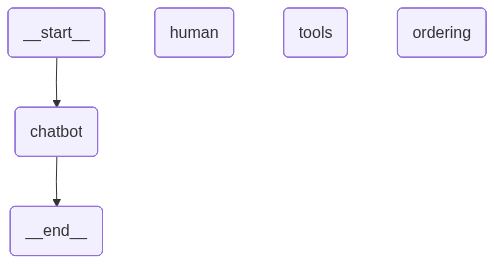

In [15]:
# Les auto-tools seront invoqués automatiquement par le ToolNode.
auto_tools = [get_menu]
tool_node = ToolNode(auto_tools)

# Les order-tools seront gérés par le nœud de commande.
order_tools = [add_to_order, confirm_order, get_order, clear_order, place_order]

# Le LLM doit connaître tous les outils, donc on les spécifie tous ici.
llm_with_tools = llm.bind_tools(auto_tools + order_tools)


graph_builder = StateGraph(OrderState)

# Nœuds
graph_builder.add_node("chatbot", chatbot_with_tools)
graph_builder.add_node("human", human_node)
graph_builder.add_node("tools", tool_node)
graph_builder.add_node("ordering", order_node)

# Chatbot -> {ordering, tools, human, END}
graph_builder.add_conditional_edges("chatbot", maybe_route_to_tools)
# Human -> {chatbot, END}
graph_builder.add_conditional_edges("human", maybe_exit_human_node)

# Tools (des deux types) reviennent toujours vers chat ensuite.
graph_builder.add_edge("tools", "chatbot")
graph_builder.add_edge("ordering", "chatbot")

graph_builder.add_edge(START, "chatbot")
graph_with_order_tools = graph_builder.compile()

Image(graph_with_order_tools.get_graph().draw_mermaid_png())

## 13. Faire tourner le système complet

Essayez par exemple :
- Commander une boisson.
- Modifier votre commande en cours de route.
- Poser une question hors commande : « Which teas are from England? »
- Constater que le graphe se termine naturellement une fois la commande passée (`q` pour quitter à tout moment).

In [16]:
# La limite de récursion par défaut pour parcourir les nœuds est de 25 - la
# fixer plus haut permet de tester une commande plus complexe avec plusieurs
# étapes et allers-retours.
config = {"recursion_limit": 100}

state = graph_with_order_tools.invoke({"messages": []}, config)

pprint(state)

Model: Welcome to the BaristaBot cafe. Type `q` to quit. How may I serve you today?
User: aka
Model: [{'type': 'text', 'text': "Je ne comprends pas. Pourrais-tu reformuler ta demande s'il te plaît ? Je peux te renseigner sur notre menu et prendre ta commande.", 'extras': {'signature': 'CpQEARFNMg9ATtHtjfE2OSKuCTyu2qH/Csox7DzZ9XSO6HvfYTDWb3oMRmwGDOUjMTKzPixzo70m71bXjZfT6AeAnj/qECYnlz0n0nuF+L0pZ8+bWfwKDxsUyIp23Ghx9vAuRAcziQN2+sdKAo0cwm1YA+Cm1NVwf1U1KM40mwF4iRAPDvQxosBfbl3O14UeGN77iIoEwSUy3kgGLIPnk8dckafMti42JsawSUicjUnH054ifHdBgCP3mBzIiTZGKcLYsNLWEhtliW1tqYPhNYyTUqgeMvx2w9xzVHPPJikQyrZt2Ze5utG/hijU9MNi7MtLe1XWNRKCHpUcARDsuNDZtuE1xD2RL617Sz9WciRwJtNsXBAb0xm3G+3n3gi+CB3mRcA7hO2n0jq418zYfzTdrEVuaDhQHcMxAI4ip1hR8WjDb5TKgB88CSF12ma0M728ZdPO48jhoQkSfTyRodrv+ewHv5aLI22vAFgk1aM44EmPUHislik+5xPeo4/jSAEZkUdhy1aOvMtqzkiqXIn8/LZpNupfR6onauyhkpKF+/E2lc5jIpLMslfgq7AJEB/QunMHhP0AbDQ2LcJHXzRtEgaiH+nGqap8agCMejYvkQP8lg7f+ZjvnJIWYrI7urPTxc9uuyHun7A3sZ+53XURSJtwKADvMUYVv1rff/AAaatP5dVNsts6JiCt6QiFTNOnRAHk3